# V2 standardized comparison: 2026-06-03 vs 2026-08-27

This notebook reduces known comparison variables before calculating improvement: identical 200 Hz low-pass bandwidth, 512 Hz sample rate, identical sample count within each upper/lower comparison, timestamp-integrity audit, and process-envelope alignment score. Only raw/unfiltered recordings are used for cross-date improvement. The vendor requirement is strictly |g| < 0.3 g at 265 wafers; available recordings are 250-wafer engineering evidence, not formal acceptance evidence.

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str((Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()) / 'scripts'))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from audit_data_comparability import standardize, envelope, align, TARGET_FS, COMMON_CUTOFF_HZ
from generate_vibration_report import load_recdata, calculate_metrics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.unicode_minus'] = False


In [2]:
DATASETS = {
    '2026-06-03 WPH249 upper/raw': Path(r'C:\ITRI\歐陽\SAA\WR503\震動量測\20260603\WPH249\上手\RecData--20260603142758.csv'),
    '2026-06-03 WPH250 upper/raw': Path(r'C:\ITRI\歐陽\SAA\WR503\震動量測\20260603\WPH250\上手\RecData--20260603153648.csv'),
    '2026-08-27 upper J5/raw': Path(r'C:\ITRI\歐陽\SAA\WR503\震動量測\20260827_vib test\濾波前\上手J5\RecData--20260827115016.csv'),
    '2026-06-03 WPH249 lower/raw': Path(r'C:\ITRI\歐陽\SAA\WR503\震動量測\20260603\WPH249\下手\RecData--20260603142937.csv'),
    '2026-06-03 WPH250 lower/raw': Path(r'C:\ITRI\歐陽\SAA\WR503\震動量測\20260603\WPH250\下手\RecData--20260603153829.csv'),
    '2026-08-27 lower J4/raw': Path(r'C:\ITRI\歐陽\SAA\WR503\震動量測\20260827_vib test\濾波前\下手J4\RecData--20260827115019.csv'),
}
GROUPS = {
    'Upper gripper': ['2026-06-03 WPH249 upper/raw', '2026-06-03 WPH250 upper/raw', '2026-08-27 upper J5/raw'],
    'Lower gripper': ['2026-06-03 WPH249 lower/raw', '2026-06-03 WPH250 lower/raw', '2026-08-27 lower J4/raw'],
}
THRESHOLD_G = 0.3
DISPLAY_MAX_POINTS = 60_000


In [3]:
raw, metadata, audit_rows = {}, {}, []
for label, path in DATASETS.items():
    frame, meta = load_recdata(path)
    raw[label], metadata[label] = frame, meta
    dt = frame.time_s.diff().dropna().median()
    expected = round((frame.time_s.iloc[-1] - frame.time_s.iloc[0]) / dt) + 1
    audit_rows.append({
        'dataset': label, 'start': meta.get('Date/Time', 'missing'),
        'inferred_Hz': 1 / dt, 'samples': len(frame),
        'duration_s': frame.time_s.iloc[-1] - frame.time_s.iloc[0],
        'timeline_missing_samples': max(0, expected - len(frame)),
        'duplicate_timestamps': frame.time_s.duplicated().sum(),
        'large_time_gaps': (frame.time_s.diff() > 1.5 * dt).sum(),
    })
audit = pd.DataFrame(audit_rows).set_index('dataset')
display(audit.round(6))

standardized = {label: standardize(frame) for label, frame in raw.items()}
windows, window_rows = {}, []
for group, labels in GROUPS.items():
    common_samples = min(len(standardized[label]) for label in labels)
    for label in labels:
        windows[label] = standardized[label].iloc[:common_samples].copy()
    window_rows.append({'group': group, 'common_samples': common_samples, 'common_duration_s': (common_samples - 1) / TARGET_FS})
print(f'Common processing: 4th-order zero-phase low-pass {COMMON_CUTOFF_HZ:.0f} Hz; sample rate {TARGET_FS:.0f} Hz')
display(pd.DataFrame(window_rows).set_index('group'))


,start,inferred_Hz,samples,duration_s,timeline_missing_samples,duplicate_timestamps,large_time_gaps
dataset,,,,,,,
2026-06-03 WPH249 upper/raw,missing,1023.992136,374784,365.999026,0,0,0
2026-06-03 WPH250 upper/raw,missing,1023.992136,377856,368.999028,0,0,0
2026-08-27 upper J5/raw,2026/08/27 11:50:16,1024.000524,359936,351.499023,0,0,0
2026-06-03 WPH249 lower/raw,missing,1023.992136,374272,365.499023,0,0,0
2026-06-03 WPH250 lower/raw,2026/06/03 15:38:29,1024.000524,374784,365.999023,0,0,0
2026-08-27 lower J4/raw,2026/08/27 11:50:19,1024.000524,363520,354.999023,0,0,0


Common processing: 4th-order zero-phase low-pass 200 Hz; sample rate 512 Hz


,common_samples,common_duration_s
group,,
Upper gripper,179968,351.498047
Lower gripper,181760,354.998047


In [4]:
alignment_rows = []
for group, labels in GROUPS.items():
    august = labels[-1]
    for benchmark in labels[:-1]:
        lag_s, correlation, overlap_s = align(envelope(standardized[august]), envelope(standardized[benchmark]))
        alignment_rows.append({
            'group': group, 'benchmark': benchmark, 'estimated_lag_s': lag_s, 'envelope_correlation': correlation,
            'overlap_s': overlap_s, 'phase_alignment_gate': 'PASS' if correlation >= 0.5 else 'FAIL',
        })
alignment_audit = pd.DataFrame(alignment_rows).set_index(['group','benchmark'])
display(alignment_audit.round(4))
print('FAIL means improvement remains conditional: timestamps alone cannot identify the same robot-motion/wafer-holding phase.')


estimated_lag_s  \
group         benchmark                                      
Upper gripper 2026-06-03 WPH249 upper/raw           -72.75   
              2026-06-03 WPH250 upper/raw           -95.00   
Lower gripper 2026-06-03 WPH249 lower/raw           -72.00   
              2026-06-03 WPH250 lower/raw          -102.00   

                                           envelope_correlation  overlap_s  \
group         benchmark                                                      
Upper gripper 2026-06-03 WPH249 upper/raw                0.0942     278.75   
              2026-06-03 WPH250 upper/raw                0.0952     256.50   
Lower gripper 2026-06-03 WPH249 lower/raw                0.0901     283.00   
              2026-06-03 WPH250 lower/raw                0.1039     253.00   

                                          phase_alignment_gate  
group         benchmark                                         
Upper gripper 2026-06-03 WPH249 upper/raw                 FAIL  
              2026-06-03 WPH250 upper/raw                 FAIL  
Lower gripper 2026-06-03 WPH249 lower/raw                 FAIL  
              2026-06-03 WPH250 lower/raw                 FAIL

FAIL means improvement remains conditional: timestamps alone cannot identify the same robot-motion/wafer-holding phase.


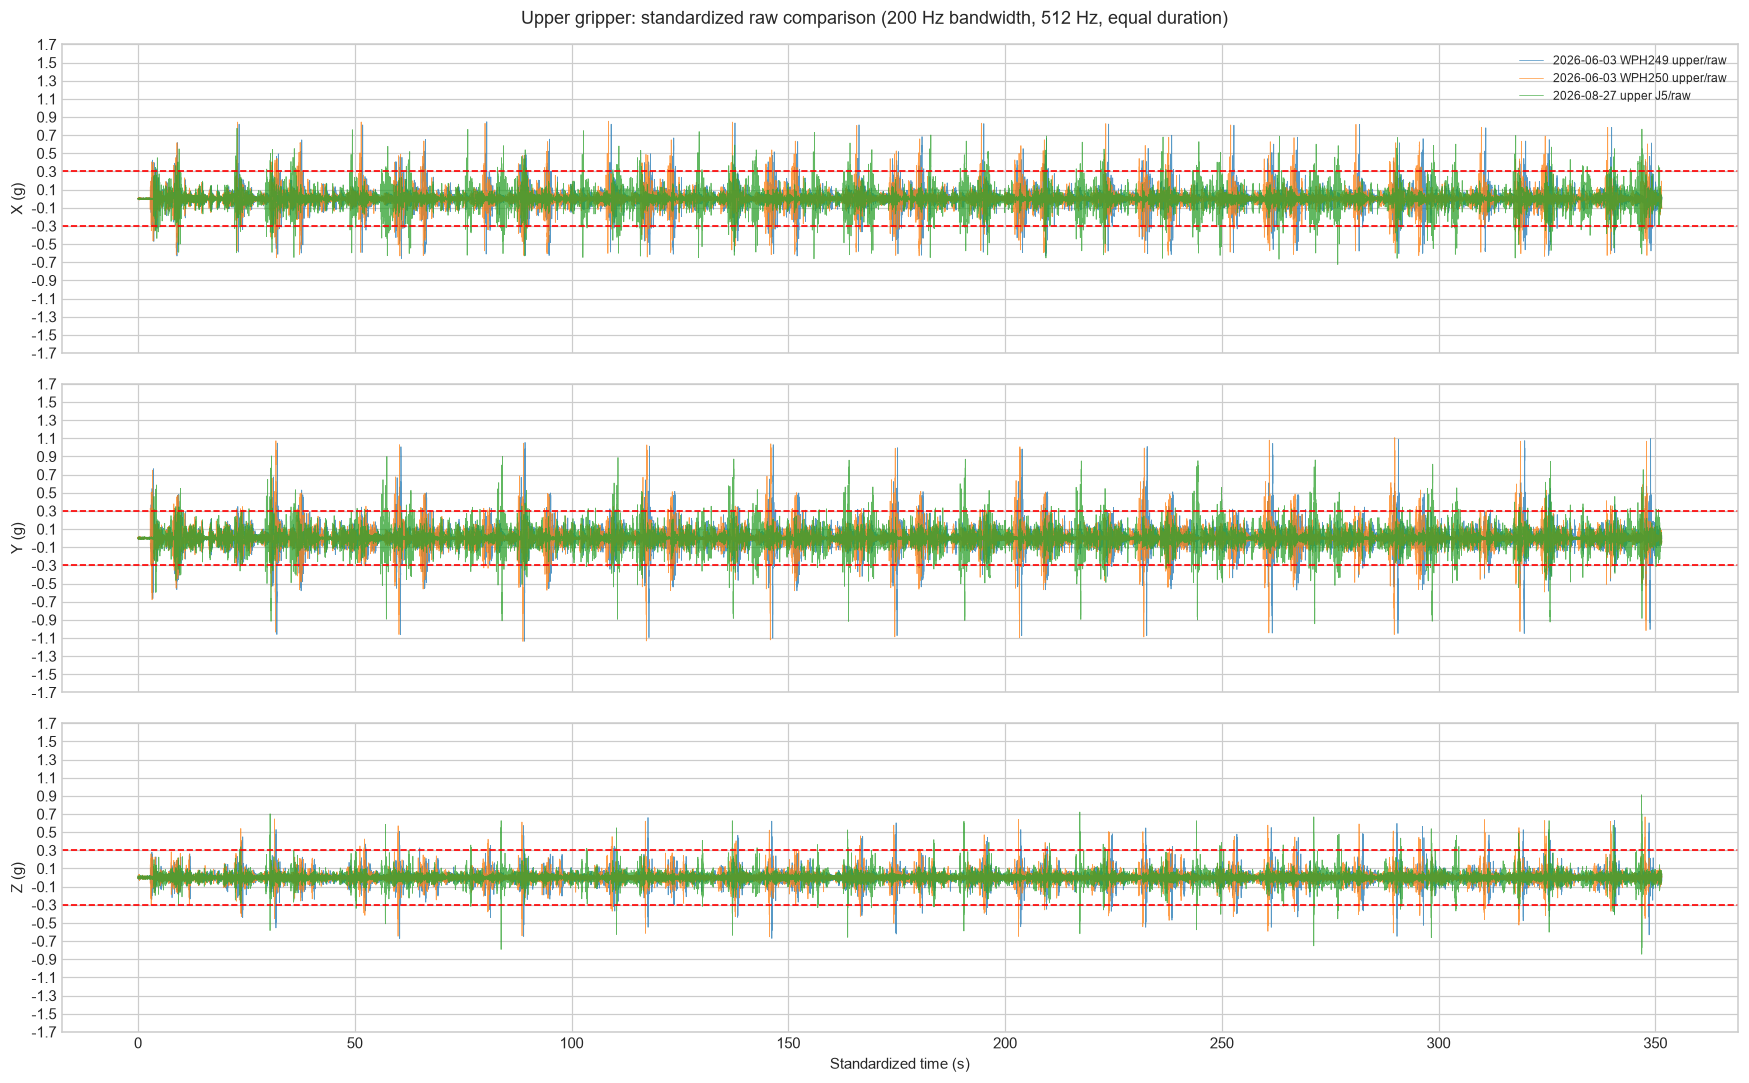

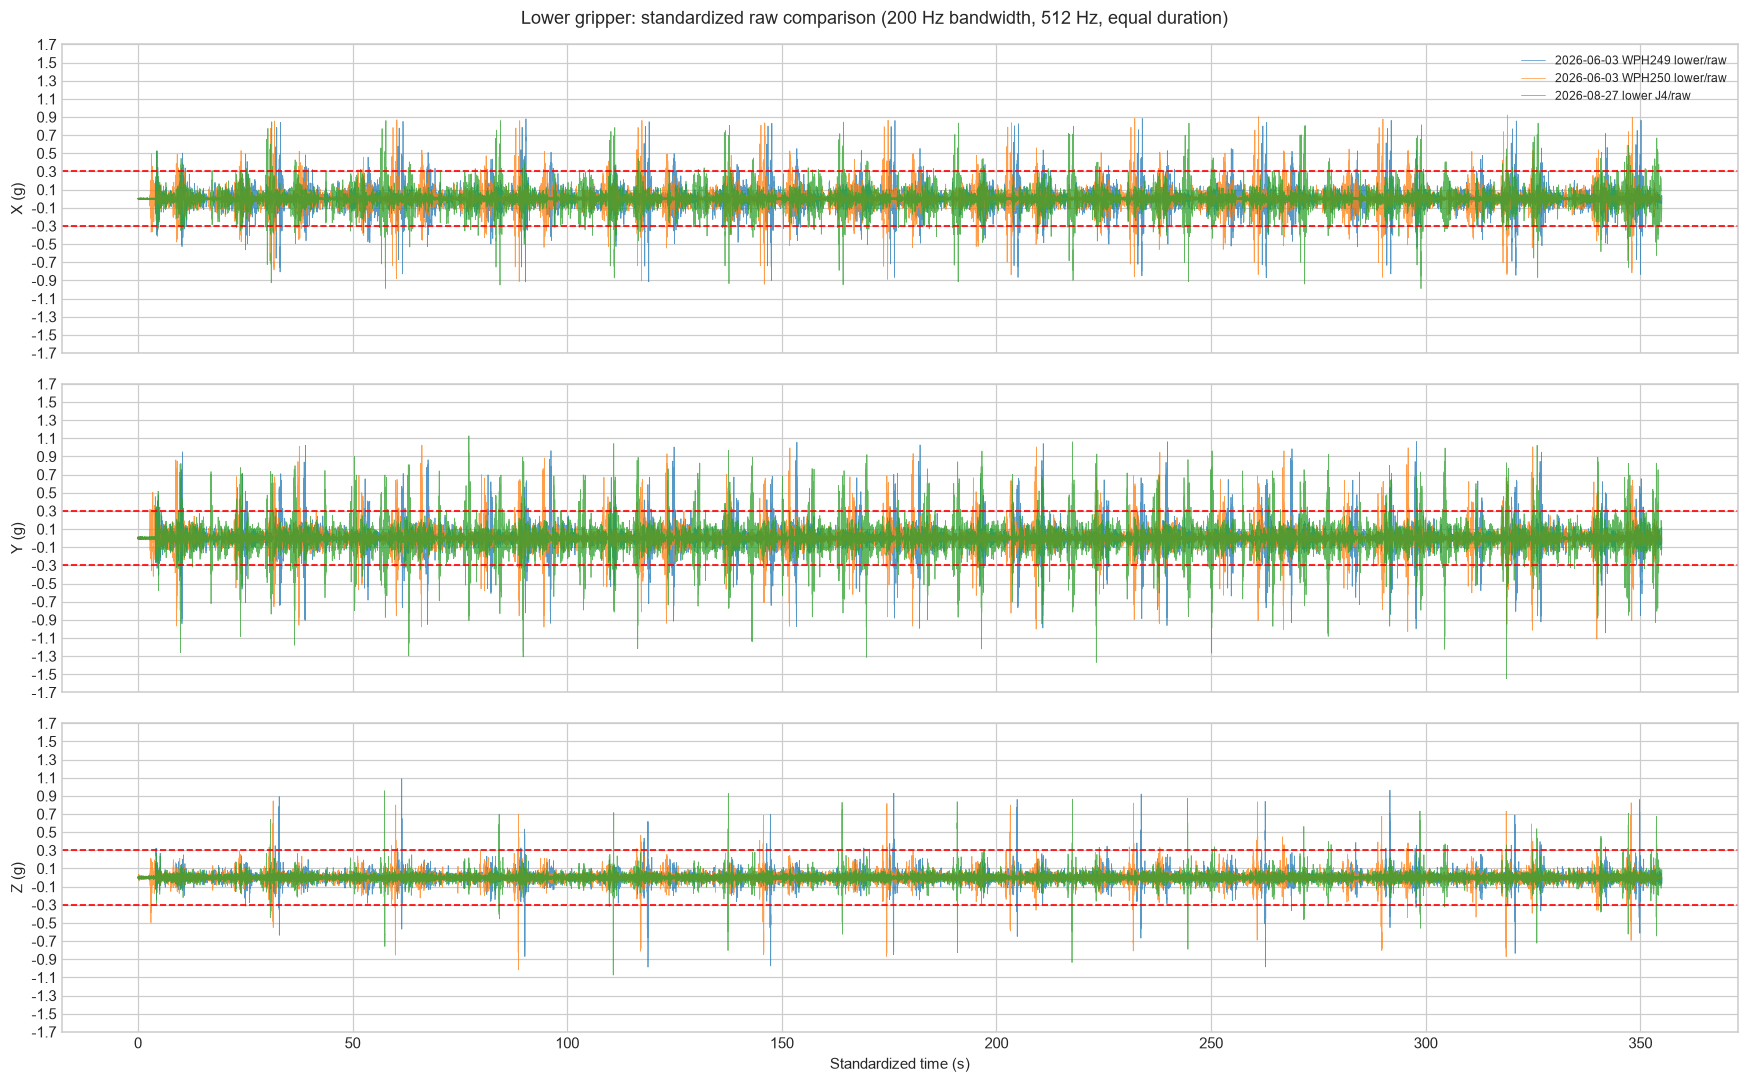

In [5]:
global_abs = max(frame[['X','Y','Z']].abs().to_numpy().max() for frame in windows.values())
y_limit = np.ceil(global_abs * 1.03 / 0.1) * 0.1
y_ticks = np.arange(-y_limit, y_limit + 0.1, 0.2)
for group, labels in GROUPS.items():
    fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True, sharey=True)
    for axis, ax in zip('XYZ', axs):
        for label in labels:
            frame = windows[label]
            step = max(1, int(np.ceil(len(frame) / DISPLAY_MAX_POINTS)))
            ax.plot(frame.time_s.iloc[::step], frame[axis].iloc[::step], lw=0.5, alpha=0.75, label=label)
        ax.axhline(THRESHOLD_G, color='red', ls='--', lw=1.1)
        ax.axhline(-THRESHOLD_G, color='red', ls='--', lw=1.1)
        ax.set_ylim(-y_limit, y_limit); ax.set_yticks(y_ticks); ax.set_ylabel(f'{axis} (g)')
    axs[0].legend(fontsize=8); axs[-1].set_xlabel('Standardized time (s)')
    fig.suptitle(f'{group}: standardized raw comparison (200 Hz bandwidth, 512 Hz, equal duration)')
    fig.tight_layout(); plt.show()


RMS_g  P99_abs_g  P99.9_abs_g  Max_abs_g  \
dataset                     axis                                               
2026-06-03 WPH249 upper/raw X     0.09799    0.43116      0.64388    0.85678   
                            Y     0.10115    0.40867      0.88062    1.13591   
                            Z     0.05308    0.22048      0.46295    0.70911   
2026-06-03 WPH250 upper/raw X     0.09791    0.43034      0.64233    0.85423   
                            Y     0.10134    0.41099      0.87687    1.13825   
                            Z     0.05289    0.22179      0.45346    0.69106   
2026-08-27 upper J5/raw     X     0.09923    0.39240      0.63478    0.79525   
                            Y     0.10545    0.40293      0.82862    0.94316   
                            Z     0.05277    0.21813      0.45306    1.15079   
2026-06-03 WPH249 lower/raw X     0.10344    0.41189      0.80168    0.94141   
                            Y     0.10659    0.47531      0.84436    1.11533   
                            Z     0.05808    0.21161      0.68834    1.08867   
2026-06-03 WPH250 lower/raw X     0.10351    0.41259      0.80325    0.95338   
                            Y     0.10699    0.47424      0.84656    1.11149   
                            Z     0.05669    0.20838      0.66988    1.01485   
2026-08-27 lower J4/raw     X     0.10803    0.41349      0.79622    0.99093   
                            Y     0.13590    0.56772      0.96304    1.58504   
                            Z     0.05507    0.20343      0.66864    1.07405   

                                  Within_pct  Exceed_pct  Events_per_min  \
dataset                     axis                                           
2026-06-03 WPH249 upper/raw X       97.47344     2.52656       119.14651   
                            Y       97.93908     2.06092       113.68421   
                            Z       99.54936     0.45064       111.29445   
2026-06-03 WPH250 upper/raw X       97.46288     2.53712       117.61024   
                            Y       97.91407     2.08593       112.14794   
                            Z       99.55214     0.44786       111.29445   
2026-08-27 upper J5/raw     X       97.64736     2.35264       138.94737   
                            Y       97.76794     2.23206        99.34566   
                            Z       99.62660     0.37340        82.95875   
2026-06-03 WPH249 lower/raw X       97.70522     2.29478       130.30986   
                            Y       97.08627     2.91373       145.18310   
                            Z       99.45092     0.54908        82.14085   
2026-06-03 WPH250 lower/raw X       97.69751     2.30249       131.49296   
                            Y       97.10607     2.89393       140.28169   
                            Z       99.48999     0.51001        90.76056   
2026-08-27 lower J4/raw     X       97.55887     2.44113       113.91549   
                            Y       95.50121     4.49879       305.07042   
                            Z       99.50924     0.49076        73.35211   

                                  Max_event_ms  
dataset                     axis                
2026-06-03 WPH249 upper/raw X        107.42188  
                            Y        103.51562  
                            Z         15.62500  
2026-06-03 WPH250 upper/raw X        109.37500  
                            Y        113.28125  
                            Z         15.62500  
2026-08-27 upper J5/raw     X         74.21875  
                            Y        103.51562  
                            Z         29.29688  
2026-06-03 WPH249 lower/raw X         91.79688  
                            Y         74.21875  
                            Z         41.01562  
2026-06-03 WPH250 lower/raw X         95.70312  
                            Y         74.21875  
                            Z         33.20312  
2026-08-27 lower J4/raw     X        109.37500  
                            Y   


RMS_g


RMS_g_benchmark  RMS_g_august  RMS_g_improvement_pct
group         axis                                                      
Upper gripper X              0.0980        0.0992                -1.3062
              Y              0.1012        0.1054                -4.1535
              Z              0.0530        0.0528                 0.4141
Lower gripper X              0.1035        0.1080                -4.4040
              Y              0.1068        0.1359               -27.2596
              Z              0.0574        0.0551                 4.0389


P99_abs_g


P99_abs_g_benchmark  P99_abs_g_august  \
group         axis                                          
Upper gripper X                  0.4307            0.3924   
              Y                  0.4098            0.4029   
              Z                  0.2211            0.2181   
Lower gripper X                  0.4122            0.4135   
              Y                  0.4748            0.5677   
              Z                  0.2100            0.2034   

                    P99_abs_g_improvement_pct  
group         axis                             
Upper gripper X                        8.9022  
              Y                        1.6830  
              Z                        1.3591  
Lower gripper X                       -0.3022  
              Y                      -19.5746  
              Z                        3.1253

...

Exceed_pct_benchmark  Exceed_pct_august  \
group         axis                                            
Upper gripper X                   2.5318             2.3526   
              Y                   2.0734             2.2321   
              Z                   0.4492             0.3734   
Lower gripper X                   2.2986             2.4411   
              Y                   2.9038             4.4988   
              Z                   0.5295             0.4908   

                    Exceed_pct_improvement_pct  
group         axis                              
Upper gripper X                         7.0778  
              Y                        -7.6511  
              Z                        16.8831  
Lower gripper X                        -6.1991  
              Y                       -54.9261  
              Z                         7.3247


Events_per_min


Events_per_min_benchmark  Events_per_min_august  \
group         axis                                                    
Upper gripper X                     118.3784               138.9474   
              Y                     112.9161                99.3457   
              Z                     111.2945                82.9587   
Lower gripper X                     130.9014               113.9155   
              Y                     142.7324               305.0704   
              Z                      86.4507                73.3521   

                    Events_per_min_improvement_pct  
group         axis                                  
Upper gripper X                           -17.3756  
              Y                            12.0181  
              Z                            25.4601  
Lower gripper X                            12.9761  
              Y                          -113.7359  
              Z                            15.1515


Max_event_ms


Max_event_ms_benchmark  Max_event_ms_august  \
group         axis                                                
Upper gripper X                   108.3984              74.2188   
              Y                   108.3984             103.5156   
              Z                    15.6250              29.2969   
Lower gripper X                    93.7500             109.3750   
              Y                    74.2188              44.9219   
              Z                    37.1094              41.0156   

                    Max_event_ms_improvement_pct  
group         axis                                
Upper gripper X                          31.5315  
              Y                           4.5045  
              Z                         -87.5000  
Lower gripper X                         -16.6667  
              Y                          39.4737  
              Z                         -10.5263

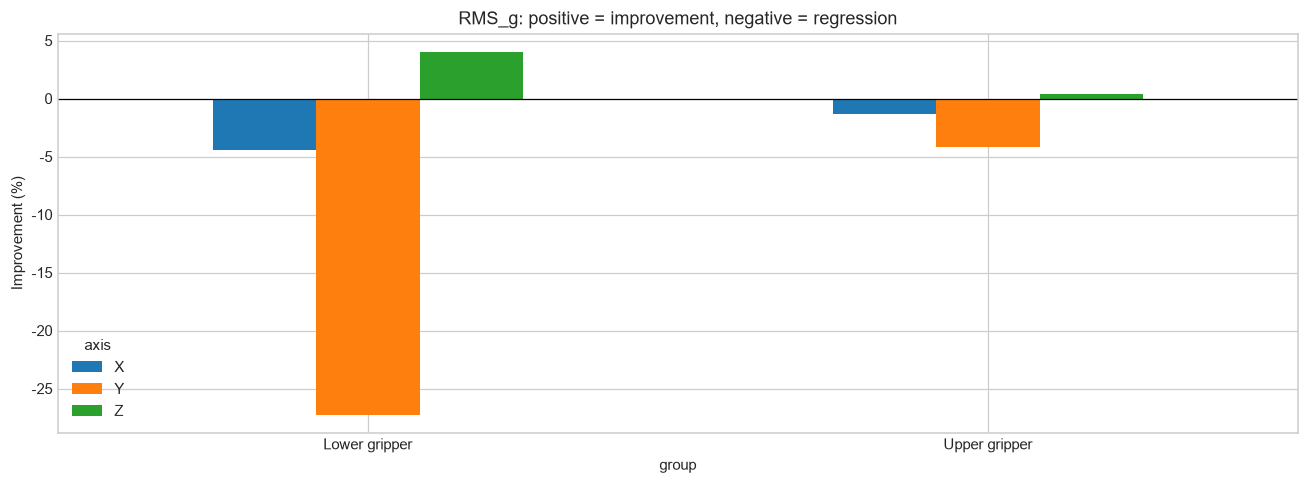

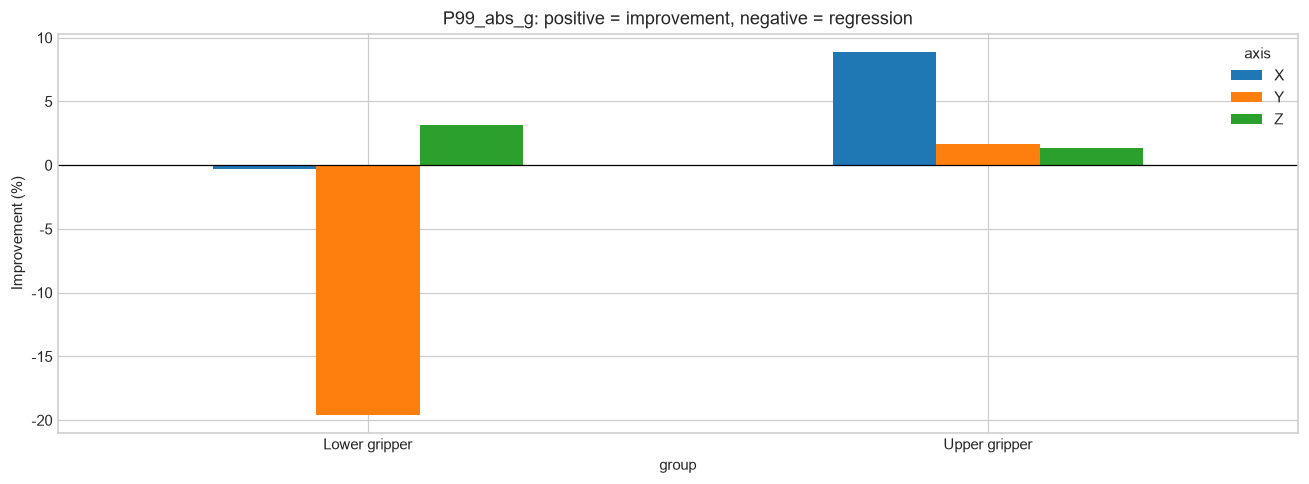

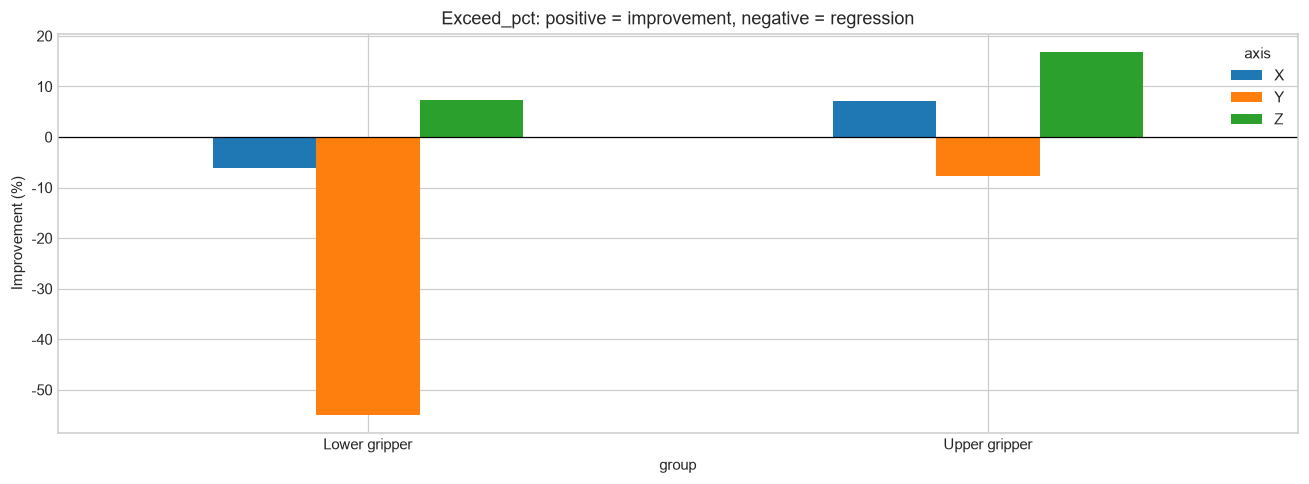

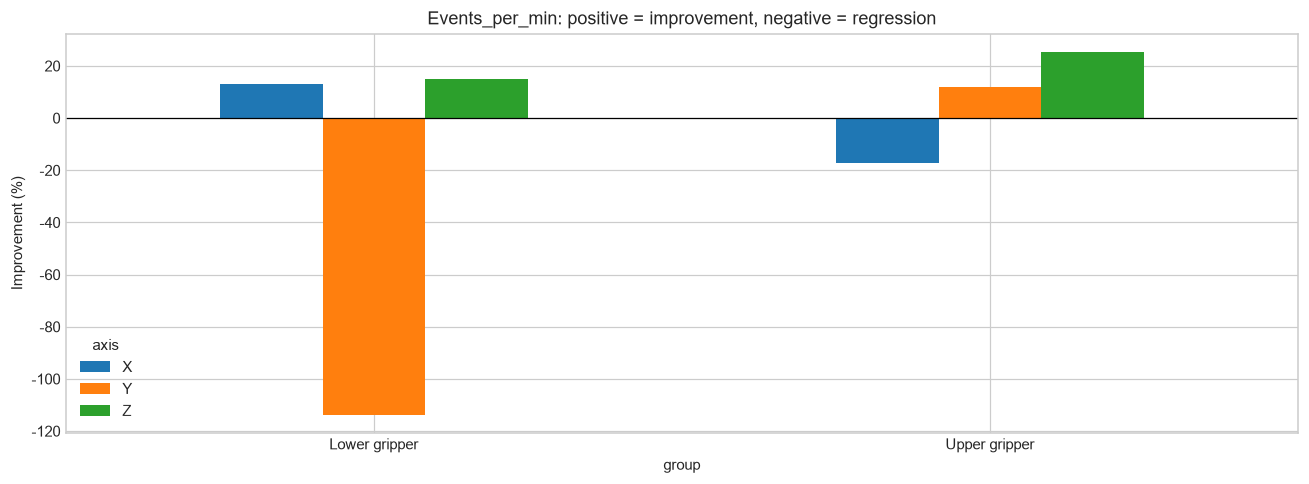

In [6]:
metrics = calculate_metrics(windows)
display(metrics[['RMS_g','P99_abs_g','P99.9_abs_g','Max_abs_g','Within_pct','Exceed_pct','Events_per_min','Max_event_ms']].round(5))

LOWER_BETTER = ['RMS_g','P99_abs_g','P99.9_abs_g','Max_abs_g','Exceed_pct','Events_per_min','Max_event_ms']
rows = []
for group, labels in GROUPS.items():
    baseline_labels, august_label = labels[:-1], labels[-1]
    baseline = pd.concat([metrics.loc[label] for label in baseline_labels]).groupby(level=0).mean()
    august = metrics.loc[august_label]
    for axis in 'XYZ':
        row = {'group': group, 'axis': axis}
        for metric in LOWER_BETTER:
            old, new = baseline.loc[axis, metric], august.loc[axis, metric]
            row[f'{metric}_benchmark'] = old; row[f'{metric}_august'] = new
            row[f'{metric}_improvement_pct'] = 100 * (old - new) / old if old else np.nan
        rows.append(row)
improvement = pd.DataFrame(rows).set_index(['group','axis'])
for metric in LOWER_BETTER:
    print(f'\n{metric}')
    display(improvement[[f'{metric}_benchmark',f'{metric}_august',f'{metric}_improvement_pct']].round(4))

for metric in ['RMS_g','P99_abs_g','Exceed_pct','Events_per_min']:
    chart = improvement[f'{metric}_improvement_pct'].unstack('axis')
    ax = chart.plot.bar(figsize=(12,4.5)); ax.axhline(0,color='black',lw=.8)
    ax.set_ylabel('Improvement (%)'); ax.set_title(f'{metric}: positive = improvement, negative = regression')
    ax.tick_params(axis='x',rotation=0); plt.tight_layout(); plt.show()


## Interpretation boundary

The standardized metrics remove sampling-rate, bandwidth, and record-length differences. They do not prove that the same motion phase or wafer-holding interval was captured. When the phase-alignment gate fails, improvement percentages are conditional engineering indicators only. Formal validation requires synchronized GPST/motion-step timestamps and a repeated 265-wafer test.